<a href="https://colab.research.google.com/github/aymanmis/DataSearch-Dashboard/blob/main/Bank_Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Customer Churn Analysis

## Objective
This project analyzes 10,000 bank customers to identify why customers leave the bank. The goal is to find patterns in customer behavior and demographics that predict churn, and provide actionable business recommendations to improve retention.

**Tools:** Python · Pandas · Seaborn · Scikit-learn &nbsp;|&nbsp; **Methods:** EDA · Feature Analysis · Random Forest Classification

## Dataset Features
- **Demographics:** Age, Gender, Geography
- **Financial:** Balance, Credit Score, Estimated Salary
- **Behavioral:** Tenure, Number of Products, Active Membership
- **Target:** Exited (1 = churned, 0 = stayed)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
df = pd.read_csv('/content/drive/MyDrive/datasets/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Data Overview


In [17]:
print("Shape:", df.shape)

print("\nDataset Info:")
df.info()

print("\nBasic Statistics:")
df.describe()

Shape: (10000, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Basic Statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Key observations:** 10,000 customers · 14 features · No missing values · Average age 39 ·
Mean balance $76,486 · Churn rate 20.4% — dataset is clean and ready for analysis.


## 2. Data Quality Check

In [24]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nDataset is clean: {df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0}")

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate Rows: 0

Dataset is clean: True


**Result:** No missing values and no duplicate rows found — no data cleaning required. Analysis can proceed on the full 10,000 customer dataset.

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


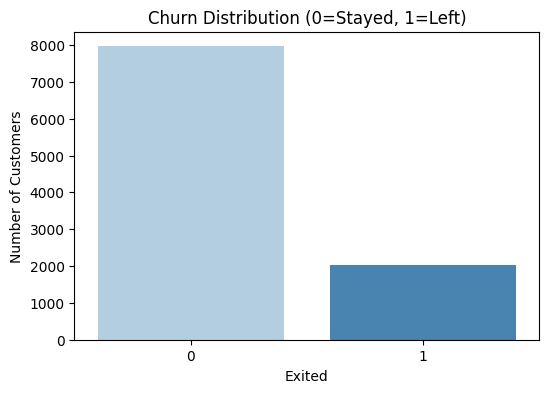

In [25]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("Churn Distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean()*100:.2f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, hue='Exited', palette='Blues', legend=False)
plt.title('Churn Distribution (0=Stayed, 1=Left)')
plt.xlabel('Exited')
plt.ylabel('Number of Customers')
plt.show()

**Finding:** 1 in 5 customers churned (20.37%) — a significant retention problem.
With 2,037 customers lost, even a 5% improvement in retention would save the bank
over 100 customers per year.

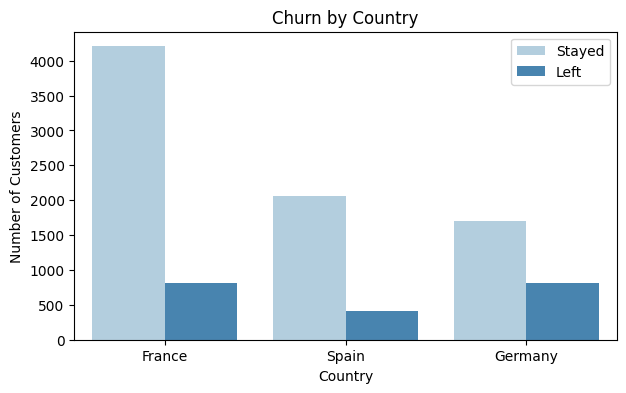

In [26]:
plt.figure(figsize=(7,4))
sns.countplot(x='Geography', hue='Exited', data=df, palette='Blues')
plt.title('Churn by Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Left'])
plt.show()

---
**Finding:** German customers churn at nearly 50% — double the rate of France (~20%) and Spain (~17%).
This is the single biggest geographic risk in the dataset and warrants an immediate
country-specific retention investigation.

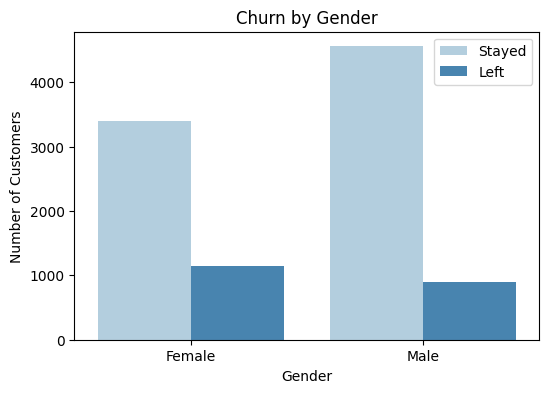

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df, palette='Blues')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Left'])
plt.show()

---
**Finding:** Female customers churn at ~25% vs ~16% for males — a 9 percentage point gap.
This suggests the bank's products or service experience may not be equally meeting
the needs of female customers.

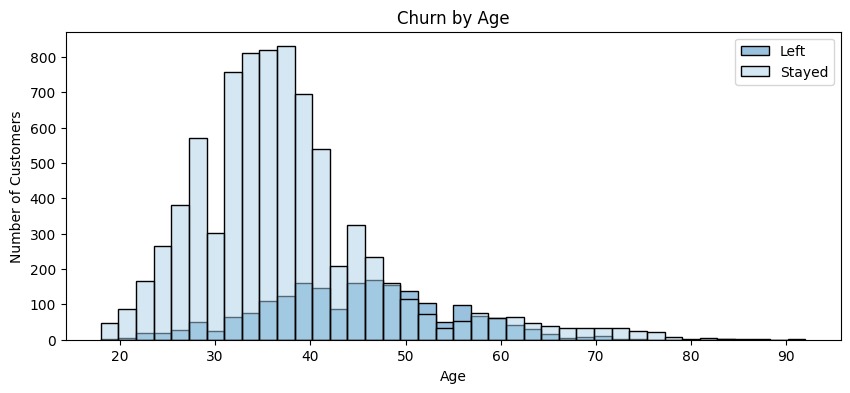

In [28]:
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Age', hue='Exited', bins=40, palette='Blues')
plt.title('Churn by Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.legend(['Left', 'Stayed'])
plt.show()

---
**Finding:** Age is the strongest demographic predictor of churn. Customers aged 40–50
churn at a significantly higher rate while under-30 customers are largely loyal.
This points to a mid-life financial needs gap the bank is currently failing to address.

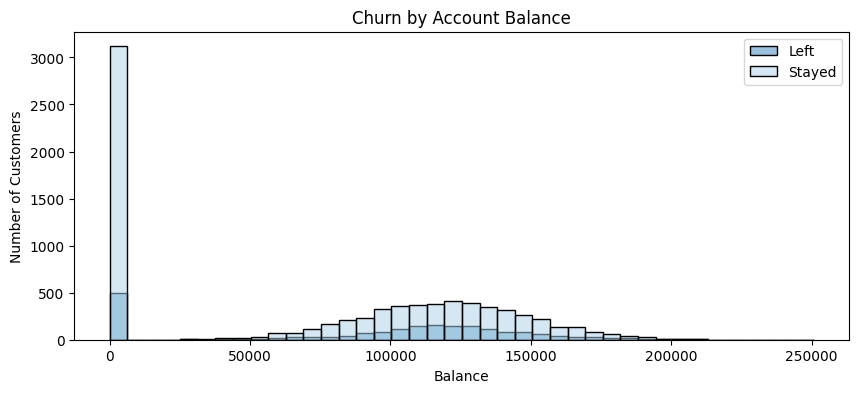

In [29]:
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Balance', hue='Exited', bins=40, palette='Blues')
plt.title('Churn by Account Balance')
plt.xlabel('Balance')
plt.ylabel('Number of Customers')
plt.legend(['Left', 'Stayed'])
plt.show()

---
**Finding:** Customers with $100k–$150k balances show the highest churn concentration —
these are mid-to-high value customers, not low-balance ones. Losing them represents
a disproportionate revenue risk compared to their share of the customer base.

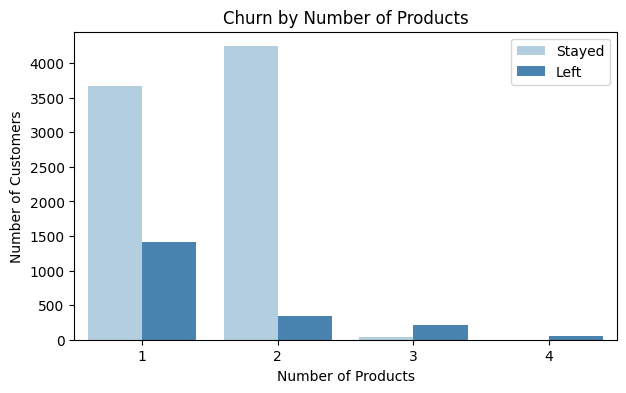

In [30]:
plt.figure(figsize=(7,4))
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='Blues')
plt.title('Churn by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Left'])
plt.show()

---
**Finding:** 2 products is the sweet spot — customers with 2 products have the lowest
churn rate. Customers with 3–4 products churn at nearly 100%, suggesting aggressive
cross-selling actively drives customers away rather than building loyalty.

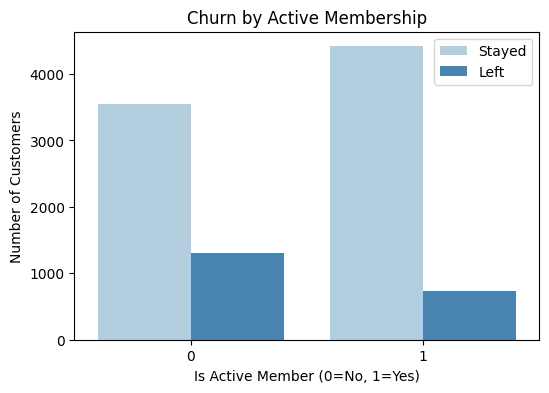

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette='Blues')
plt.title('Churn by Active Membership')
plt.xlabel('Is Active Member (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Left'])
plt.show()

---
**Finding:** Inactive members churn at roughly double the rate of active members (~27% vs ~14%).
Engagement is one of the most actionable levers the bank has — unlike age or geography,
activity level can be directly influenced through targeted campaigns.

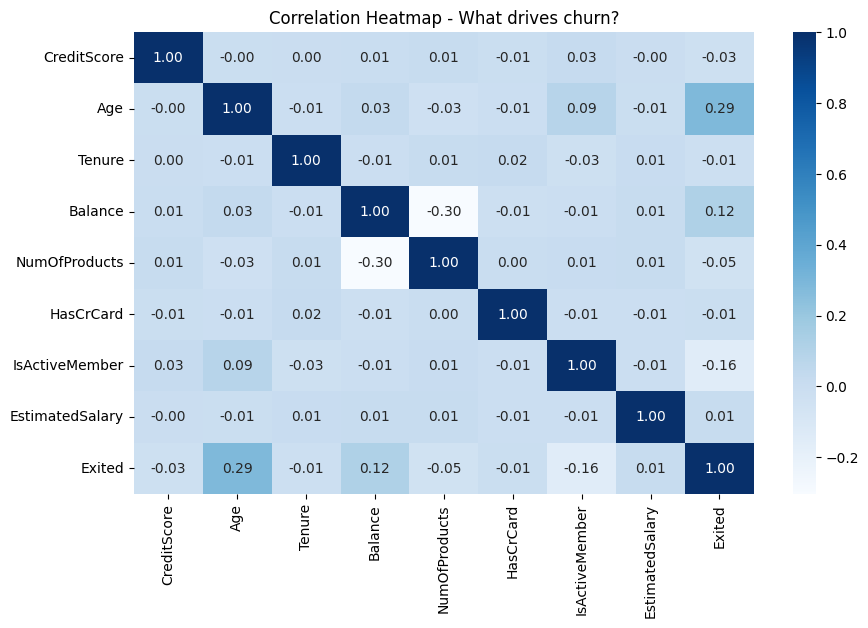

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap - What drives churn?')
plt.show()

---
**Finding:** Age has the strongest correlation with churn (0.29), confirming it as the
top demographic predictor. IsActiveMember shows a negative correlation (-0.16),
meaning active members are significantly less likely to leave.

## Model Building

In [33]:
df_model = df.copy()
le = LabelEncoder()
df_model['Geography'] = le.fit_transform(df_model['Geography'])
df_model['Gender'] = le.fit_transform(df_model['Gender'])

X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Data is ready for modeling! ✅")

Training set size: (8000, 10)
Testing set size: (2000, 10)
Data is ready for modeling! ✅


80/20 train-test split on 10,000 records — 8,000 samples for training, 2,000 held out for unbiased evaluation.

In [35]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 86.45%

Detailed Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



**Model Performance:** 86.45% overall accuracy. The model is strong at identifying
loyal customers (96% recall) but misses roughly half of churners (47% recall on class 1).
This is a common challenge with imbalanced datasets — in a real deployment, the cost
of missing a churner outweighs a false alarm, so threshold tuning would be recommended.

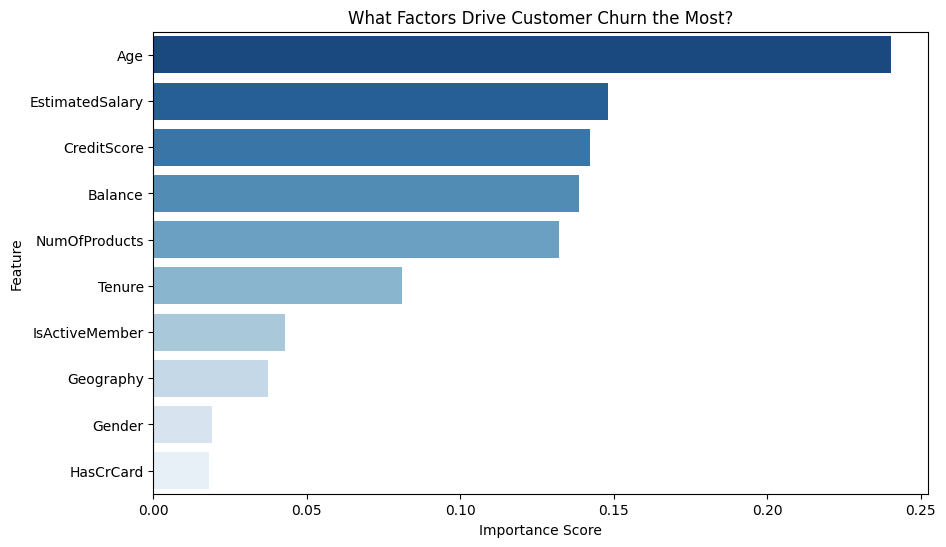

In [37]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, hue='Feature', palette='Blues_r', legend=False)
plt.title('What Factors Drive Customer Churn the Most?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

---
**Finding:** Age is the dominant churn predictor, nearly double the importance of
NumOfProducts and Balance. This confirms the EDA findings — a targeted retention
strategy for 40–50 year old, high-balance customers would address the highest-risk segment.

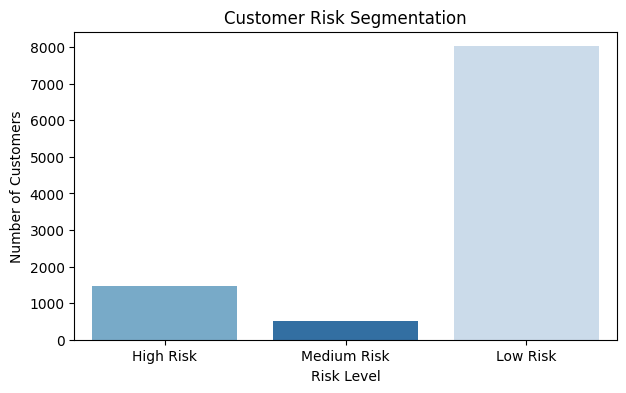

Risk_Segment
Low Risk       8019
High Risk      1462
Medium Risk     519
Name: count, dtype: int64


In [38]:
df_model['Churn_Probability'] = rf_model.predict_proba(X)[:,1]

def risk_segment(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_model['Risk_Segment'] = df_model['Churn_Probability'].apply(risk_segment)

plt.figure(figsize=(7,4))
sns.countplot(x='Risk_Segment', data=df_model, hue='Risk_Segment',
              palette='Blues', legend=False,
              order=['High Risk', 'Medium Risk', 'Low Risk'])
plt.title('Customer Risk Segmentation')
plt.xlabel('Risk Level')
plt.ylabel('Number of Customers')
plt.show()

print(df_model['Risk_Segment'].value_counts())

---
**Finding:** 1,462 customers are High Risk (≥70% churn probability) and require immediate
intervention. The 519 Medium Risk customers represent a critical prevention opportunity —
retaining them before they migrate to High Risk is more cost-effective than recovering churners.

## Business Recommendations

Based on this analysis and the predictive model (86.45% accuracy), I recommend:

1. **Investigate Germany urgently** — ~50% churn rate is double France and Spain, suggesting a country-specific service or product issue
2. **Launch retention programs for customers aged 40–50** — the highest-risk demographic and strongest predictor of churn
3. **Re-engage inactive members** — a targeted engagement campaign could cut their churn rate in half
4. **Cap cross-selling at 2 products per customer** — beyond 2 products, churn reaches nearly 100%
5. **Create a VIP program for $100k–$150k balance customers** — high-value segment with disproportionate revenue risk
6. **Act immediately on the 1,462 High Risk customers** — flagged by the model with ≥70% churn probability

## Tools & Methods
Python · Pandas · Seaborn · Matplotlib · Scikit-learn · Random Forest Classifier